## Wharton Data Science Competition

### Phase 1a: Team Performance Analysis
**Create team power rankings**
Based on season data, rank the 32 teams using the underlying team performance. But this isn’t just
about win-loss records. Your rankings should reflect the overall strength and quality of the teams.

**Plan Outline**:

## Power Rankings Pipeline (from slice-level WHL data)

### 0) Quick EDA (raw table)
- For a few `game_id`s, check which columns are cumulative vs per-slice:
  - cumulative → use `max` in aggregation (often goals, shots, xG, assists, PIM)
  - per-slice → use `sum` (often `toi`)
  - descriptors → use `first` (home_team, away_team, went_ot)

### 1) Aggregate slices → game-level (1 row per game)
- `game_df = df.groupby("game_id").agg({...})`
  - identifiers/descriptors: `first`
  - cumulative stats: `max`
  - per-slice stats: `sum`
- (optional) create game-level derived columns: `xg_diff = home_xg - away_xg`, `shot_diff`, etc.

### 2) Expand game-level → team-game (2 rows per game)
- Build `team_combo_df` with canonical columns:
  - `game_id, team, opponent, is_home, went_ot`
  - `goals_for, goals_against`
  - `xg_for, xg_against`
  - `shots_for, shots_against`
  - (optional) TOI-weighted / per-60 features

### 3) Add create engineering fields
**NOTE:** Since we're creating power rankings, we don't have to split the data because we will be evaluating the teams based on all the given metrics + engineered fields

- We create engineering fields on the
ADD MORE


In [1]:
# Standard Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/whl_2025.csv")

In [3]:
df.head().T

,0,1,2,3,4
game_id,game_1,game_1,game_1,game_1,game_1
record_id,record_1,record_2,record_3,record_4,record_5
home_team,thailand,thailand,thailand,thailand,thailand
away_team,pakistan,pakistan,pakistan,pakistan,pakistan
went_ot,0,0,0,0,0
home_off_line,PP_kill_dwn,second_off,first_off,second_off,second_off
home_def_pairing,PP_kill_dwn,second_def,second_def,first_def,second_def
away_off_line,PP_up,second_off,second_off,second_off,first_off
away_def_pairing,PP_up,second_def,second_def,first_def,second_def
home_goalie,player_id_142,player_id_142,player_id_142,player_id_142,player_id_142


In [4]:
data_dict = {
    "game_id": "Unique identifier for a game (e.g., 'game_1').",
    "record_id": "Unique identifier for a lineup matchup segment within a game (one row = one segment).",
    "home_team": "Home team name/ID.",
    "away_team": "Away team name/ID.",
    "went_ot": "1 if game went to overtime, else 0.",

    "home_off_line": {
        "__definition__": "Home forward unit label during the segment.",
        "first_off": "Home 1st forward line (top line).",
        "second_off": "Home 2nd forward line.",
        "PP_up": "Home power-play forward unit (home team has a man advantage).",
        "PP_kill_dwn": "Home penalty-kill forward unit (home team is shorthanded).",
        "empty_net_line": "Home extra-attacker forward unit (goalie pulled / late-game)."
    },
    "home_def_pairing": {
        "__definition__": "Home defense unit label during the segment.",
        "first_def": "Home 1st defense pairing.",
        "second_def": "Home 2nd defense pairing.",
        "PP_up": "Home power-play defense unit (on the man advantage).",
        "PP_kill_dwn": "Home penalty-kill defense unit (shorthanded).",
        "empty_net_line": "Home extra-attacker/late-game defense configuration (goalie pulled)."
    },
    "away_off_line": {
        "__definition__": "Away forward unit label during the segment.",
        "first_off": "Away 1st forward line (top line).",
        "second_off": "Away 2nd forward line.",
        "PP_up": "Away power-play forward unit (away team has a man advantage).",
        "PP_kill_dwn": "Away penalty-kill forward unit (away team is shorthanded).",
        "empty_net_line": "Away extra-attacker forward unit (goalie pulled / late-game)."
    },
    "away_def_pairing": {
        "__definition__": "Away defense unit label during the segment.",
        "first_def": "Away 1st defense pairing.",
        "second_def": "Away 2nd defense pairing.",
        "PP_up": "Away power-play defense unit (on the man advantage).",
        "PP_kill_dwn": "Away penalty-kill defense unit (shorthanded).",
        "empty_net_line": "Away extra-attacker/late-game defense configuration (goalie pulled)."
    },

    "home_goalie": {
        "__definition__": "Home goalie identifier during the segment.",
        "player_id_*": "A specific goalie player ID (e.g., 'player_id_142').",
        "empty_net": "No goalie on ice (goalie pulled; extra attacker)."
    },
    "away_goalie": {
        "__definition__": "Away goalie identifier during the segment.",
        "player_id_*": "A specific goalie player ID (e.g., 'player_id_106').",
        "empty_net": "No goalie on ice (goalie pulled; extra attacker)."
    },

    "toi": "Segment duration in seconds (time that exact matchup configuration was on the ice).",

    "home_assists": "Assists recorded by the home team during the segment.",
    "home_shots": "Shots by the home team during the segment (as defined by your source; often shots on goal).",
    "home_xg": "Expected goals generated by the home team during the segment.",
    "home_max_xg": "Maximum single-shot xG value for the home team within the segment.",
    "home_goals": "Goals scored by the home team during the segment.",

    "away_assists": "Assists recorded by the away team during the segment.",
    "away_shots": "Shots by the away team during the segment.",
    "away_xg": "Expected goals generated by the away team during the segment.",
    "away_max_xg": "Maximum single-shot xG value for the away team within the segment.",
    "away_goals": "Goals scored by the away team during the segment.",

    "home_penalties_committed": "Number of penalties committed by the home team during the segment.",
    "home_penalty_minutes": "Total penalty minutes assessed to the home team during the segment.",
    "away_penalties_committed": "Number of penalties committed by the away team during the segment.",
    "away_penalty_minutes": "Total penalty minutes assessed to the away team during the segment."
}

# Example access:
# data_dict["home_off_line"]["PP_kill_dwn"]


In [5]:
# get the positions
positions_df = pd.DataFrame({col:  pd.Series(df[col].unique()) for col in df.columns[5:9]}) # pd.Series() to pad with NaN to same length
positions_df

,home_off_line,home_def_pairing,away_off_line,away_def_pairing
0,PP_kill_dwn,PP_kill_dwn,PP_up,PP_up
1,second_off,second_def,second_off,second_def
2,first_off,first_def,first_off,first_def
3,empty_net_line,empty_net_line,PP_kill_dwn,PP_kill_dwn
4,PP_up,PP_up,empty_net_line,empty_net_line


In [6]:
data_dict["home_off_line"]

{'__definition__': 'Home forward unit label during the segment.',
 'first_off': 'Home 1st forward line (top line).',
 'second_off': 'Home 2nd forward line.',
 'PP_up': 'Home power-play forward unit (home team has a man advantage).',
 'PP_kill_dwn': 'Home penalty-kill forward unit (home team is shorthanded).',
 'empty_net_line': 'Home extra-attacker forward unit (goalie pulled / late-game).'}

In [7]:
# Number of games
len(df["game_id"].unique())

1312

In [8]:
df.describe()

,went_ot,toi,home_assists,home_shots,home_xg,home_max_xg,home_goals,away_assists,away_shots,away_xg,away_max_xg,away_goals,home_penalties_committed,home_penalty_minutes,away_penalties_committed,away_penalty_minutes
count,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.000000,25827.00000,25827.000000,25827.00000,25827.000000
mean,0.210942,190.194902,0.245054,1.400240,0.158953,0.066332,0.157045,0.211445,1.329113,0.142801,0.062455,0.135440,0.31649,0.646494,0.34491,0.703605
std,0.407985,153.702230,0.798532,2.046256,0.305636,0.060490,0.476548,0.714388,1.875248,0.264191,0.058003,0.427517,1.31447,2.695040,1.43678,2.940398
min,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
25%,0.000000,92.645000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
50%,0.000000,156.190000,0.000000,1.000000,0.089800,0.080100,0.000000,0.000000,1.000000,0.082500,0.074500,0.000000,0.00000,0.000000,0.00000,0.000000
75%,0.000000,237.985000,0.000000,2.000000,0.187800,0.105000,0.000000,0.000000,2.000000,0.175200,0.099600,0.000000,0.00000,0.000000,0.00000,0.000000
max,1.000000,1559.670000,13.000000,28.000000,5.543500,0.270700,7.000000,13.000000,23.000000,4.412300,0.262200,7.000000,16.00000,34.000000,19.00000,38.000000


In [9]:
df["game_id"].unique(), len(df["game_id"].unique())

(array(['game_1', 'game_10', 'game_100', ..., 'game_997', 'game_998',
        'game_999'], dtype=object),
 1312)

#### Agregating Data

- **Note**: The stats aren't cumulative because the numbers oscilate up and down

- Numerical columns to aggregate
  - toi
  - home_goals, away_goals
  - home_assists, away_assists
  - home_shots, away_shots
  - home_xg, away_xg
  - home_penalties_committied, away_penalties_committed
  - home_penalty_minutes, away_penalty_minutes

- Columns NOT to aggregate
  - home_max_xg, away_max_xg

- Labels/identifiers
  - home_team, away_team, went_ot

- Excluded columns like home_off_line because they were all strings

In [10]:
df.head().T

,0,1,2,3,4
game_id,game_1,game_1,game_1,game_1,game_1
record_id,record_1,record_2,record_3,record_4,record_5
home_team,thailand,thailand,thailand,thailand,thailand
away_team,pakistan,pakistan,pakistan,pakistan,pakistan
went_ot,0,0,0,0,0
home_off_line,PP_kill_dwn,second_off,first_off,second_off,second_off
home_def_pairing,PP_kill_dwn,second_def,second_def,first_def,second_def
away_off_line,PP_up,second_off,second_off,second_off,first_off
away_def_pairing,PP_up,second_def,second_def,first_def,second_def
home_goalie,player_id_142,player_id_142,player_id_142,player_id_142,player_id_142


In [11]:
# aggregate data
agg_dict = {
    # identifiers
    "home_team": "first",
    "away_team": "first",

    # Numerical (sum)
    "toi": "sum",
    "home_goals": "sum",
    "away_goals": "sum",
    "home_assists": "sum",
    "away_assists": "sum",
    "home_shots": "sum",
    "away_shots": "sum",
    "home_xg": "sum",
    "away_xg": "sum",
    "home_penalties_committed": "sum",
    "away_penalties_committed": "sum",
    "home_penalty_minutes": "sum",
    "away_penalty_minutes": "sum"
}

## as_index=False is keeping game_id as normal column in the output
game_df = df.groupby("game_id", as_index=False).agg(agg_dict)
# game_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/game_id_compressed_whl.csv")
game_df

,game_id,home_team,away_team,toi,home_goals,away_goals,home_assists,away_assists,home_shots,away_shots,home_xg,away_xg,home_penalties_committed,away_penalties_committed,home_penalty_minutes,away_penalty_minutes
0,game_1,thailand,pakistan,3599.99,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12
1,game_10,switzerland,kazakhstan,3600.01,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0
2,game_100,serbia,rwanda,3600.00,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20
3,game_1000,brazil,netherlands,3600.03,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12
4,game_1001,india,morocco,3599.99,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,game_995,vietnam,mexico,3919.98,4,3,4,4,30,23,2.9710,2.8999,8,6,16,12
1308,game_996,kazakhstan,indonesia,3600.00,0,5,0,7,12,31,1.2391,3.3882,6,3,12,6
1309,game_997,canada,south_korea,3600.01,3,5,5,9,22,34,2.0455,3.6745,9,6,18,12
1310,game_998,switzerland,uae,3600.00,4,2,2,1,35,21,3.2982,2.2124,8,8,16,16


In [12]:
# creating separate home/away dataframes then concatenating them
home = pd.DataFrame({
    "game_id": game_df["game_id"],
    "team": game_df["home_team"],
    "opponent": game_df["away_team"],
    "toi": game_df["toi"],
    "is_home": 1,

    "goals_for": game_df["home_goals"],
    "goals_against": game_df["away_goals"],

    "assists_for": game_df["home_assists"],
    "assists_against": game_df["away_assists"],

    "shots_for": game_df["home_shots"],
    "shots_against": game_df["away_shots"],

    "xg_for": game_df["home_xg"],
    "xg_against": game_df["away_xg"],

    "pens_committed_for": game_df["home_penalties_committed"],
    "pens_committed_against": game_df["away_penalties_committed"],

    "pim_for": game_df["home_penalty_minutes"],
    "pim_against": game_df["away_penalty_minutes"]
})

# creating separate home/away dataframes then concatenating them
away = pd.DataFrame({
    "game_id": game_df["game_id"],
    "team": game_df["away_team"],
    "opponent": game_df["home_team"],
    "toi": game_df["toi"],
    "is_home": 0,

    "goals_for": game_df["away_goals"],
    "goals_against": game_df["home_goals"],

    "assists_for": game_df["away_assists"],
    "assists_against": game_df["home_assists"],

    "shots_for": game_df["away_shots"],
    "shots_against": game_df["home_shots"],

    "xg_for": game_df["away_xg"],
    "xg_against": game_df["home_xg"],

    "pens_committed_for": game_df["away_penalties_committed"],
    "pens_committed_against": game_df["home_penalties_committed"],

    "pim_for": game_df["away_penalty_minutes"],
    "pim_against": game_df["home_penalty_minutes"]
})

team_combo_df = pd.concat([home, away], ignore_index=True) # ignore_index means create an entirely new DataFrame structure
team_combo_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16


In [13]:
# putting the games together
team_combo_df.sort_values(by="game_id")

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12
1312,game_1,pakistan,thailand,3599.99,0,3,1,6,2,24,21,2.7516,2.8231,6,8,12,16
1313,game_10,kazakhstan,switzerland,3600.01,0,3,4,4,7,30,20,3.3189,1.9254,0,10,0,20
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,game_997,canada,south_korea,3600.01,1,3,5,5,9,22,34,2.0455,3.6745,9,6,18,12
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16
1310,game_998,switzerland,uae,3600.00,1,4,2,2,1,35,21,3.2982,2.2124,8,8,16,16
1311,game_999,oman,thailand,3600.01,1,2,3,4,6,29,24,2.7900,3.4265,9,7,18,14


In [14]:
# exporting the csv
# team_combo_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/game_aggregated_whl.csv")

In [15]:
team_combo = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/game_aggregated_whl.csv").drop(columns="Unnamed: 0")
team_combo

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16


In [16]:
# making a duplicate to add extra fields
extra_combo = team_combo
extra_combo

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16


In [17]:
# Establish winners (create a true criteria that we want to test for)
extra_combo["win"] = (extra_combo["goals_for"] > extra_combo["goals_against"]).astype(int)
extra_combo

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12,0
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0,1
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20,0
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12,1
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16,0
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12,1
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18,1
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16,0


In [18]:
# checking amount of wins vs loss
extra_combo["win"].sum()

np.int64(1312)

In [19]:
# extra_combo.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/FINAL_aggregated.csv", index=False)

In [20]:
agg_df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/FINAL_aggregated.csv")
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12,0
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0,1
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20,0
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12,1
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16,0
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12,1
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18,1
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16,0



# Main engineering fields for pure hockey power rankings (team-level)
We are doing unsupervised ranking :)
This section is mainly math/statistics oriented because we are doing unsupervised ranking.

**Supervised** is like having an answer key. The model learns off of the correct answers and adapts its algorithm.

**Unsupervised ranking** does not give us an answer key. Therefore, its harder for the model to learn because there is no feedback. That's why this section is math oriented.

## A) Game-level (row-level) engineered fields (each row = team in a game)
**Results**
- `goal_diff` = `goals_for - goals_against`

**Process / performance**
- `xg_diff` = `xg_for - xg_against`
- `shot_diff` = `shots_for - shots_against`

**Shares (more stable than raw counts)**
- `xg_share` = `xg_for / (xg_for + xg_against + eps)`
- `shot_share` = `shots_for / (shots_for + shots_against + eps)`

**Optional normalization (only if TOI varies meaningfully)**
- `xg_diff_per60` = `60 * xg_diff / (toi + eps)`
- `shot_diff_per60` = `60 * shot_diff / (toi + eps)`
- (optional) `xg_for_per60`, `xg_against_per60`, `shots_for_per60`, `shots_against_per60`

---

## B) Team-level aggregation fields (group by `team`)
**Volume / sample size**
- `GP` = number of games (rows) for the team

**Results**
- `win_pct` = mean(`win`)
- `avg_goal_diff` = mean(`goal_diff`)

**Process**
- `avg_xg_diff` (or `avg_xg_diff_per60`)
- `avg_shot_diff` (or `avg_shot_diff_per60`)
- (optional) `avg_xg_share`, `avg_shot_share`

---

## C) Composite ranking field (recommended)
Standardize key team metrics across teams (z-scores), for example:
- `power_score` = `0.55*Z(xg_diff) + 0.25*Z(shot_diff) + 0.15*Z(goal_diff) + 0.05*Z(win_pct)`

Using per60 versions in the z-scores.



#### A) Game-level (row-level) engineered fields (each row = team in a game)

In [21]:
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12,0
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0,1
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20,0
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12,1
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16,0
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12,1
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18,1
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16,0


In [22]:
# Goal Difference
agg_df["goal_diff"] = agg_df["goals_for"] - agg_df["goals_against"]
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win,goal_diff
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12,0,-2
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0,1,1
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20,0,-1
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12,1,5
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16,0,-1
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12,1,5
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18,1,2
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16,0,-2


In [23]:
# Xg Difference
agg_df["xg_diff"] = agg_df["xg_for"] - agg_df["xg_against"]
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,shots_against,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win,goal_diff,xg_diff
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,24,2.8231,2.7516,8,6,16,12,0,-2,0.0715
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,30,1.9254,3.3189,10,0,20,0,1,1,-1.3935
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,27,3.6712,3.0240,8,10,16,20,0,-1,0.6472
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,27,3.5905,2.5261,10,6,20,12,1,5,1.0644
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,29,3.4592,3.7658,8,8,16,16,0,-1,-0.3066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,30,2.8999,2.9710,6,8,12,16,0,-1,-0.0711
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,12,3.3882,1.2391,3,6,6,12,1,5,2.1491
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,22,3.6745,2.0455,6,9,12,18,1,2,1.6290
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,35,2.2124,3.2982,8,8,16,16,0,-2,-1.0858


In [24]:
# Shot difference
agg_df["shot_diff"] = agg_df["shots_for"] - agg_df["shots_against"]
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,xg_for,xg_against,pens_committed_for,pens_committed_against,pim_for,pim_against,win,goal_diff,xg_diff,shot_diff
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,2.8231,2.7516,8,6,16,12,0,-2,0.0715,-3
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,1.9254,3.3189,10,0,20,0,1,1,-1.3935,-10
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,3.6712,3.0240,8,10,16,20,0,-1,0.6472,3
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,3.5905,2.5261,10,6,20,12,1,5,1.0644,5
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,3.4592,3.7658,8,8,16,16,0,-1,-0.3066,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,2.8999,2.9710,6,8,12,16,0,-1,-0.0711,-7
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,3.3882,1.2391,3,6,6,12,1,5,2.1491,19
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,3.6745,2.0455,6,9,12,18,1,2,1.6290,12
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,2.2124,3.2982,8,8,16,16,0,-2,-1.0858,-14


In [25]:
# Shares - essentially the % of shots each team took to show how dominant they were as the raw xg/shot might not be representative
eps = 1e-6 # creating epsilon to prevent division by 0
agg_df["shot_share"] = agg_df["shots_for"]/(agg_df["shots_for"] + agg_df["shots_against"] + eps)
agg_df["xg_share"] = agg_df["xg_for"]/(agg_df["xg_for"] + agg_df["xg_against"] + eps)
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,pens_committed_for,pens_committed_against,pim_for,pim_against,win,goal_diff,xg_diff,shot_diff,shot_share,xg_share
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,8,6,16,12,0,-2,0.0715,-3,0.466667,0.506413
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,10,0,20,0,1,1,-1.3935,-10,0.400000,0.367141
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,8,10,16,20,0,-1,0.6472,3,0.526316,0.548333
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,10,6,20,12,1,5,1.0644,5,0.542373,0.587009
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,8,8,16,16,0,-1,-0.3066,3,0.524590,0.478782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,6,8,12,16,0,-1,-0.0711,-7,0.433962,0.493945
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,3,6,6,12,1,5,2.1491,19,0.720930,0.732219
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,6,9,12,18,1,2,1.6290,12,0.607143,0.642395
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,8,8,16,16,0,-2,-1.0858,-14,0.375000,0.401481


In [26]:
# The average time on ice (around 4% more than an average game 3600 seconds or 60 minutes)
(agg_df["toi"].mean() - 3600)/3600

np.float64(0.04000756690379414)

In [27]:
# Since the average time varies, we will convert it all to per_60
# Note: we don't need to convert shot_share and xg_share as that is already a ratio
agg_df["xg_diff_per60"] = (agg_df["xg_diff"]*3600)/agg_df["toi"]
agg_df["shot_diff_per60"] = (agg_df["shot_diff"]*3600)/agg_df["toi"]

agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,pim_for,pim_against,win,goal_diff,xg_diff,shot_diff,shot_share,xg_share,xg_diff_per60,shot_diff_per60
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,16,12,0,-2,0.0715,-3,0.466667,0.506413,0.071500,-3.000008
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,20,0,1,1,-1.3935,-10,0.400000,0.367141,-1.393496,-9.999972
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,16,20,0,-1,0.6472,3,0.526316,0.548333,0.647200,3.000000
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,20,12,1,5,1.0644,5,0.542373,0.587009,1.064391,4.999958
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,16,16,0,-1,-0.3066,3,0.524590,0.478782,-0.306601,3.000008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,12,16,0,-1,-0.0711,-7,0.433962,0.493945,-0.065296,-6.428604
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,6,12,1,5,2.1491,19,0.720930,0.732219,2.149100,19.000000
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,12,18,1,2,1.6290,12,0.607143,0.642395,1.628995,11.999967
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,16,16,0,-2,-1.0858,-14,0.375000,0.401481,-1.085800,-14.000000


In [28]:
# Checking to see if share columns are in correct range (0, 1)
agg_df[["xg_share", "shot_share"]].describe()

,xg_share,shot_share
count,2624.000000,2624.000000
mean,0.500000,0.500000
std,0.107681,0.084170
min,0.092958,0.160000
25%,0.427176,0.444444
50%,0.500000,0.500000
75%,0.572823,0.555556
max,0.907042,0.840000


In [29]:
# Check to see if per60 columns are correct
agg_df[["xg_diff_per60", "shot_diff_per60"]].describe()

,xg_diff_per60,shot_diff_per60
count,2624.000000,2624.000000
mean,0.000000,0.000000
std,1.280606,8.690078
min,-6.148717,-33.999906
25%,-0.799223,-5.999971
50%,0.000000,0.000000
75%,0.799223,5.999971
max,6.148717,33.999906


In [30]:
# to make sure that there aren't any 0 problems
agg_df[["xg_diff_per60","shot_diff_per60"]].abs().describe()

,xg_diff_per60,shot_diff_per60
count,2624.000000,2624.000000
mean,0.987093,6.877861
std,0.815615,5.309845
min,0.002500,0.000000
25%,0.361026,2.999992
50%,0.799748,5.999975
75%,1.387348,9.999972
max,6.148717,33.999906


In [31]:
# games played
agg_df["GP"] = agg_df.groupby("team")["game_id"].transform("count") # we are adding transform("count") so it returns a series the same length as agg_df
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,pim_against,win,goal_diff,xg_diff,shot_diff,shot_share,xg_share,xg_diff_per60,shot_diff_per60,GP
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,12,0,-2,0.0715,-3,0.466667,0.506413,0.071500,-3.000008,82
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,0,1,1,-1.3935,-10,0.400000,0.367141,-1.393496,-9.999972,82
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,20,0,-1,0.6472,3,0.526316,0.548333,0.647200,3.000000,82
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,12,1,5,1.0644,5,0.542373,0.587009,1.064391,4.999958,82
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,16,0,-1,-0.3066,3,0.524590,0.478782,-0.306601,3.000008,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,16,0,-1,-0.0711,-7,0.433962,0.493945,-0.065296,-6.428604,82
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,12,1,5,2.1491,19,0.720930,0.732219,2.149100,19.000000,82
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,18,1,2,1.6290,12,0.607143,0.642395,1.628995,11.999967,82
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,16,0,-2,-1.0858,-14,0.375000,0.401481,-1.085800,-14.000000,82


In [32]:
# Penalties in minutes per 60 minutes
agg_df["pim_for_per60"] = (agg_df["pim_for"]*3600)/agg_df["toi"]
agg_df["pim_against_per60"] = (agg_df["pim_against"]*3600)/agg_df["toi"]
agg_df["pim_diff_per60"] = agg_df["pim_for_per60"] - agg_df["pim_against_per60"]

agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,xg_diff,shot_diff,shot_share,xg_share,xg_diff_per60,shot_diff_per60,GP,pim_for_per60,pim_against_per60,pim_diff_per60
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,0.0715,-3,0.466667,0.506413,0.071500,-3.000008,82,16.000044,12.000033,4.000011
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,-1.3935,-10,0.400000,0.367141,-1.393496,-9.999972,82,19.999944,0.000000,19.999944
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,0.6472,3,0.526316,0.548333,0.647200,3.000000,82,16.000000,20.000000,-4.000000
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,1.0644,5,0.542373,0.587009,1.064391,4.999958,82,19.999833,11.999900,7.999933
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,-0.3066,3,0.524590,0.478782,-0.306601,3.000008,82,16.000044,16.000044,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,-0.0711,-7,0.433962,0.493945,-0.065296,-6.428604,82,11.020464,14.693953,-3.673488
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,2.1491,19,0.720930,0.732219,2.149100,19.000000,82,6.000000,12.000000,-6.000000
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,1.6290,12,0.607143,0.642395,1.628995,11.999967,82,11.999967,17.999950,-5.999983
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,-1.0858,-14,0.375000,0.401481,-1.085800,-14.000000,82,16.000000,16.000000,0.000000


In [33]:
# Mean (% wins)
agg_df["win_pct"] = agg_df.groupby("team")["win"].transform("mean")
agg_df

,game_id,team,opponent,toi,is_home,goals_for,goals_against,assists_for,assists_against,shots_for,...,shot_diff,shot_share,xg_share,xg_diff_per60,shot_diff_per60,GP,pim_for_per60,pim_against_per60,pim_diff_per60,win_pct
0,game_1,thailand,pakistan,3599.99,1,1,3,2,6,21,...,-3,0.466667,0.506413,0.071500,-3.000008,82,16.000044,12.000033,4.000011,0.609756
1,game_10,switzerland,kazakhstan,3600.01,1,4,3,7,4,20,...,-10,0.400000,0.367141,-1.393496,-9.999972,82,19.999944,0.000000,19.999944,0.439024
2,game_100,serbia,rwanda,3600.00,1,4,5,7,10,30,...,3,0.526316,0.548333,0.647200,3.000000,82,16.000000,20.000000,-4.000000,0.500000
3,game_1000,brazil,netherlands,3600.03,1,5,0,6,0,32,...,5,0.542373,0.587009,1.064391,4.999958,82,19.999833,11.999900,7.999933,0.707317
4,game_1001,india,morocco,3599.99,1,2,3,4,6,32,...,3,0.524590,0.478782,-0.306601,3.000008,82,16.000044,16.000044,0.000000,0.597561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,game_995,mexico,vietnam,3919.98,0,3,4,4,4,23,...,-7,0.433962,0.493945,-0.065296,-6.428604,82,11.020464,14.693953,-3.673488,0.463415
2620,game_996,indonesia,kazakhstan,3600.00,0,5,0,7,0,31,...,19,0.720930,0.732219,2.149100,19.000000,82,6.000000,12.000000,-6.000000,0.500000
2621,game_997,south_korea,canada,3600.01,0,5,3,9,5,34,...,12,0.607143,0.642395,1.628995,11.999967,82,11.999967,17.999950,-5.999983,0.475610
2622,game_998,uae,switzerland,3600.00,0,2,4,1,2,21,...,-14,0.375000,0.401481,-1.085800,-14.000000,82,16.000000,16.000000,0.000000,0.463415


Side Exploration: Which teams have the highest and lowest win%

In [34]:
# creating separate DataFrame containing only teams and their win% (with largest on top)
team_pct_df = agg_df[["team", "win_pct"]].sort_values(by=["win_pct"], ascending=False)
# we are dropping all the copies and re-setting index to get it numbered from 0-31
team_pct_df.drop_duplicates().reset_index(drop=True)

,team,win_pct
0,brazil,0.707317
1,netherlands,0.658537
2,peru,0.634146
3,thailand,0.609756
4,india,0.597561
5,pakistan,0.597561
6,china,0.573171
7,iceland,0.560976
8,panama,0.560976
9,philippines,0.524390


In [35]:
# Average of win% should be 50%
team_pct_df["win_pct"].mean()

np.float64(0.5)

In [36]:
# agg_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/aggregated_plus_engineering.csv", index=False)

#### Combining the data into a `team_df`, z scoring the data to creat z_team_df, then creating power scores like power_df
We will be utilizing all of our feature engineered fields. We will also normalize them to produce our final `power_score`.

In [37]:
agg_df.head().T

,0,1,2,3,4
game_id,game_1,game_10,game_100,game_1000,game_1001
team,thailand,switzerland,serbia,brazil,india
opponent,pakistan,kazakhstan,rwanda,netherlands,morocco
toi,3599.99,3600.01,3600.0,3600.03,3599.99
is_home,1,1,1,1,1
goals_for,1,4,4,5,2
goals_against,3,3,5,0,3
assists_for,2,7,7,6,4
assists_against,6,4,10,0,6
shots_for,21,20,30,32,32


In [38]:
agg_df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/aggregated_plus_engineering.csv")

agg_dict = {
    "game_id": "count",
    "win": "mean",
    "goal_diff": "mean",
    "shot_share": "mean",
    "xg_share": "mean",
    "shot_diff_per60": "mean",
    "xg_diff_per60": "mean",
    "pim_diff_per60": "mean"
}

rename_dict = {
    "game_id": "GP",
    "win": "win_pct",
    "goal_diff": "avg_goal_diff",
    "shot_share": "avg_shot_share",
    "xg_share": "avg_xg_share",
    "shot_diff_per60": "avg_shot_diff_per60",
    "xg_diff_per60": "avg_xg_diff_per60",
    "pim_diff_per60": "avg_pim_diff_per60"
}

# groupby gives an object
team_df = agg_df.groupby(["team"], as_index=False).agg(agg_dict).rename(columns=rename_dict)
team_df

,team,GP,win_pct,avg_goal_diff,avg_shot_share,avg_xg_share,avg_shot_diff_per60,avg_xg_diff_per60,avg_pim_diff_per60
0,brazil,82,0.707317,1.060976,0.491651,0.551236,-0.919668,0.600289,0.789278
1,canada,82,0.439024,-0.524390,0.511889,0.506991,1.288806,0.080400,-0.847935
2,china,82,0.573171,0.560976,0.494708,0.533883,-0.231107,0.429386,-0.870493
3,ethiopia,82,0.524390,0.243902,0.474079,0.477556,-2.900991,-0.271283,0.921107
4,france,82,0.451220,-0.292683,0.525994,0.530982,2.546768,0.395033,-3.684635
5,germany,82,0.439024,-0.256098,0.492650,0.486374,-0.635603,-0.160504,-1.204808
6,guatemala,82,0.512195,-0.060976,0.488419,0.522876,-1.322216,0.259114,-0.248040
7,iceland,82,0.560976,0.353659,0.475200,0.480973,-2.578833,-0.211009,1.834582
8,india,82,0.597561,0.341463,0.519653,0.505987,1.974255,0.022670,-2.049244
9,indonesia,82,0.500000,0.134146,0.505969,0.474974,0.705434,-0.270493,-3.217021


In [39]:
xg_per_shot = agg_df.groupby("team")["xg_for"].sum()/agg_df.groupby("team")["shots_for"].sum()
xg_per_shot

,0
team,
brazil,0.126031
canada,0.109209
china,0.118700
ethiopia,0.109224
france,0.118512
germany,0.116524
guatemala,0.107885
iceland,0.110927
india,0.100858


In [40]:
# the reason why we have to sum everythinb before averaging is because every single game's factors very so a 30 shot game is equal to five 6 shot games.
# By averaging the totals, each individual game has less weight
# We are mapping a the series (xg_per_shot) to the team
team_df["xg_per_shot"] = team_df["team"].map(xg_per_shot)

In [41]:
# team_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/team_net_stats.csv", index=False)

In [42]:
team_df = team_df.sort_values(["win_pct"], ascending=False).reset_index(drop=True)
team_df

,team,GP,win_pct,avg_goal_diff,avg_shot_share,avg_xg_share,avg_shot_diff_per60,avg_xg_diff_per60,avg_pim_diff_per60,xg_per_shot
0,brazil,82,0.707317,1.060976,0.491651,0.551236,-0.919668,0.600289,0.789278,0.126031
1,netherlands,82,0.658537,0.841463,0.511549,0.541969,1.346185,0.487234,-2.469479,0.114171
2,peru,82,0.634146,0.951220,0.539549,0.536807,3.694844,0.365754,-0.188457,0.105820
3,thailand,82,0.609756,0.560976,0.523465,0.570191,2.503338,0.861023,0.287953,0.125634
4,india,82,0.597561,0.341463,0.519653,0.505987,1.974255,0.022670,-2.049244,0.100858
5,pakistan,82,0.597561,0.621951,0.552986,0.549298,5.695211,0.630638,2.035020,0.115874
6,china,82,0.573171,0.560976,0.494708,0.533883,-0.231107,0.429386,-0.870493,0.118700
7,iceland,82,0.560976,0.353659,0.475200,0.480973,-2.578833,-0.211009,1.834582,0.110927
8,panama,82,0.560976,0.512195,0.506860,0.514605,0.711113,0.186589,-1.288595,0.115192
9,ethiopia,82,0.524390,0.243902,0.474079,0.477556,-2.900991,-0.271283,0.921107,0.109224


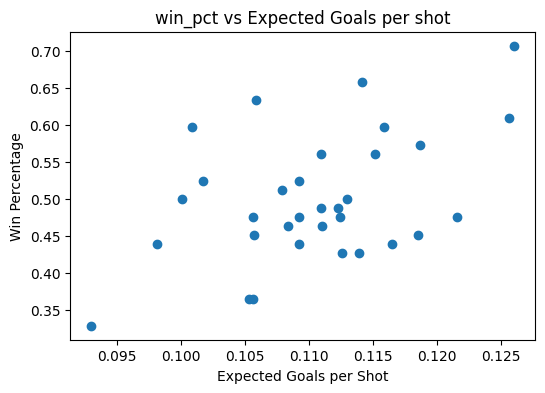

In [43]:
plt.figure(figsize=(6, 4))
plt.scatter(team_df["xg_per_shot"], team_df["win_pct"])

plt.xlabel("Expected Goals per Shot")
plt.ylabel("Win Percentage")
plt.title("win_pct vs Expected Goals per shot")

plt.show()


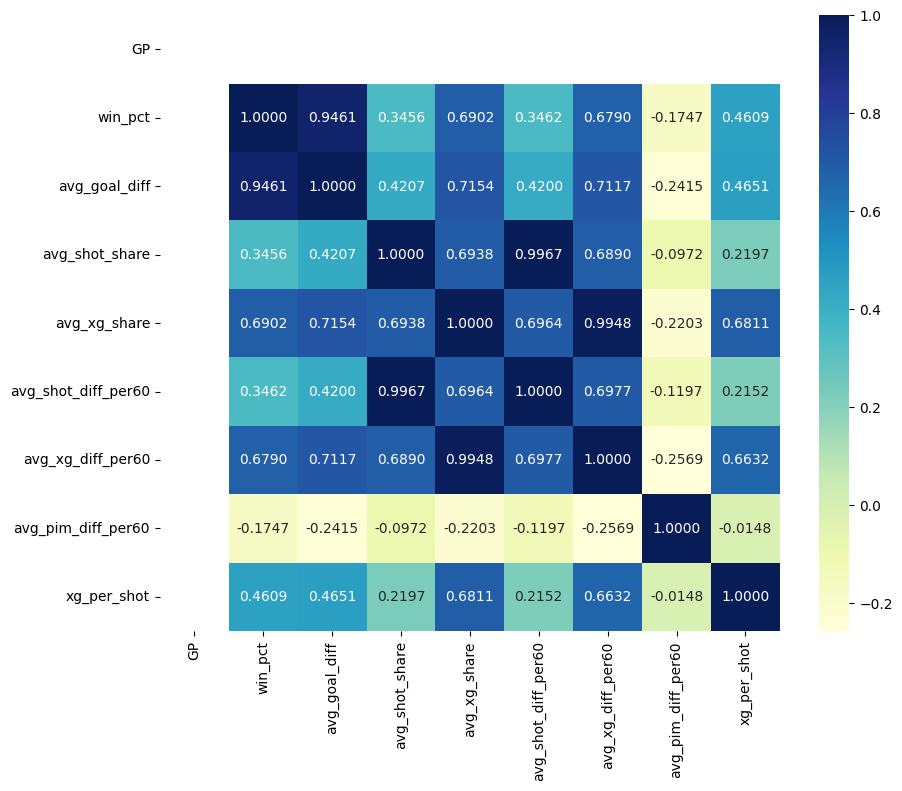

In [44]:
corr = team_df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".4f", cmap="YlGnBu")
plt.show()

In [45]:
team_df

,team,GP,win_pct,avg_goal_diff,avg_shot_share,avg_xg_share,avg_shot_diff_per60,avg_xg_diff_per60,avg_pim_diff_per60,xg_per_shot
0,brazil,82,0.707317,1.060976,0.491651,0.551236,-0.919668,0.600289,0.789278,0.126031
1,netherlands,82,0.658537,0.841463,0.511549,0.541969,1.346185,0.487234,-2.469479,0.114171
2,peru,82,0.634146,0.951220,0.539549,0.536807,3.694844,0.365754,-0.188457,0.105820
3,thailand,82,0.609756,0.560976,0.523465,0.570191,2.503338,0.861023,0.287953,0.125634
4,india,82,0.597561,0.341463,0.519653,0.505987,1.974255,0.022670,-2.049244,0.100858
5,pakistan,82,0.597561,0.621951,0.552986,0.549298,5.695211,0.630638,2.035020,0.115874
6,china,82,0.573171,0.560976,0.494708,0.533883,-0.231107,0.429386,-0.870493,0.118700
7,iceland,82,0.560976,0.353659,0.475200,0.480973,-2.578833,-0.211009,1.834582,0.110927
8,panama,82,0.560976,0.512195,0.506860,0.514605,0.711113,0.186589,-1.288595,0.115192
9,ethiopia,82,0.524390,0.243902,0.474079,0.477556,-2.900991,-0.271283,0.921107,0.109224


In [46]:
data_dict["game_id"]

"Unique identifier for a game (e.g., 'game_1')."

In [47]:
from scipy.stats import zscore
stats_df = team_df.drop(columns=["team", "GP"])
stats_df

,win_pct,avg_goal_diff,avg_shot_share,avg_xg_share,avg_shot_diff_per60,avg_xg_diff_per60,avg_pim_diff_per60,xg_per_shot
0,0.707317,1.060976,0.491651,0.551236,-0.919668,0.600289,0.789278,0.126031
1,0.658537,0.841463,0.511549,0.541969,1.346185,0.487234,-2.469479,0.114171
2,0.634146,0.951220,0.539549,0.536807,3.694844,0.365754,-0.188457,0.105820
3,0.609756,0.560976,0.523465,0.570191,2.503338,0.861023,0.287953,0.125634
4,0.597561,0.341463,0.519653,0.505987,1.974255,0.022670,-2.049244,0.100858
5,0.597561,0.621951,0.552986,0.549298,5.695211,0.630638,2.035020,0.115874
6,0.573171,0.560976,0.494708,0.533883,-0.231107,0.429386,-0.870493,0.118700
7,0.560976,0.353659,0.475200,0.480973,-2.578833,-0.211009,1.834582,0.110927
8,0.560976,0.512195,0.506860,0.514605,0.711113,0.186589,-1.288595,0.115192
9,0.524390,0.243902,0.474079,0.477556,-2.900991,-0.271283,0.921107,0.109224


In [48]:
zstats_df = stats_df.apply(zscore)
zstats_df = zstats_df.add_prefix("z_")
zstats_df.head()

,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot
0,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816
1,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015
2,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834
3,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820
4,1.154701,0.681787,0.857095,0.172238,0.831145,0.055285,-0.988772,-1.306158


In [49]:
z_team_df = pd.concat([team_df[["team", "GP"]], zstats_df], axis=1)
z_team_df.head()

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot
0,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816
1,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834
3,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820
4,india,82,1.154701,0.681787,0.857095,0.172238,0.831145,0.055285,-0.988772,-1.306158


In [50]:
# z_team_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/zscored_Team.csv")

In [51]:
power_df = z_team_df.copy()
power_df.head()

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot
0,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816
1,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834
3,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820
4,india,82,1.154701,0.681787,0.857095,0.172238,0.831145,0.055285,-0.988772,-1.306158


In [52]:
# self made power_score
weights = {
    "z_avg_xg_diff_per60": 0.25,
    "z_avg_shot_diff_per60": 0.15,
    "z_avg_goal_diff": 0.20,
    "z_win_pct": 0.15,
    "z_avg_xg_share": 0.10,
    "z_avg_shot_share": 0.10,
    "z_xg_per_shot": 0.03,
    "z_avg_pim_diff_per60": 0.02,
}

power_df["power_score"] = sum(z_team_df[key] * value for key, value in weights.items())

In [53]:
power_df = power_df.sort_values("power_score", ascending=False).reset_index(drop=True)
power_df.head()

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot,power_score
0,pakistan,82,1.154701,1.241826,2.310820,1.418222,2.397636,1.537960,0.981909,0.734542,1.580285
1,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820,1.470770
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834,1.331924
3,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816,1.281699
4,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015,1.161914


In [54]:
power_df["z_power_score"] = zscore(power_df["power_score"].to_numpy())
power_df

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot,power_score,z_power_score
0,pakistan,82,1.154701,1.241826,2.310820,1.418222,2.397636,1.537960,0.981909,0.734542,1.580285,1.908516
1,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820,1.470770,1.776255
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834,1.331924,1.608570
3,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816,1.281699,1.547912
4,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015,1.161914,1.403248
5,uk,82,-0.288675,0.803535,0.827627,1.031357,0.796550,1.025781,-1.045273,1.514868,0.703772,0.849948
6,china,82,0.866025,1.120079,-0.230778,0.974765,-0.097294,1.047159,-0.420018,1.118521,0.700669,0.846201
7,panama,82,0.721688,1.022681,0.299173,0.420162,0.299373,0.455041,-0.621755,0.641871,0.550210,0.664491
8,mexico,82,-0.433013,-0.413942,1.099176,1.156254,1.106109,1.139783,0.563107,0.078440,0.542280,0.654914
9,india,82,1.154701,0.681787,0.857095,0.172238,0.831145,0.055285,-0.988772,-1.306158,0.492029,0.594225


In [55]:
# power_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/power_ranking.csv")

In [56]:
strength_df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/zscored_Team.csv").drop(columns="Unnamed: 0")
strength_df.head()

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot
0,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816
1,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834
3,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820
4,india,82,1.154701,0.681787,0.857095,0.172238,0.831145,0.055285,-0.988772,-1.306158


In [57]:
# excluding z_win_pct because we want true strength not affected by win%
from sklearn.decomposition import PCA
features = [col for col in strength_df.columns if col.startswith("z_") and col not in ["z_win_pct"]]
features

# turning all features to numbers
X = strength_df[features].to_numpy()

pca = PCA(n_components=1)
pca1 = pca.fit_transform(X).ravel()
strength_df["power_score_pca"] = pca1
strength_df = strength_df.sort_values("power_score_pca", ascending=False)

In [58]:
strength_df = strength_df.reset_index(drop=True)
strength_df.head()

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot,power_score_pca
0,pakistan,82,1.154701,1.241826,2.310820,1.418222,2.397636,1.537960,0.981909,0.734542,3.817500
1,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820,3.779966
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834,2.736451
3,uk,82,-0.288675,0.803535,0.827627,1.031357,0.796550,1.025781,-1.045273,1.514868,2.497326
4,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015,2.467792


In [59]:
strength_df["z_power_score"] = zscore(strength_df["power_score_pca"].to_numpy())

In [60]:
# strength_df.to_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/power_ranking_PCA.csv")

In [61]:
strength_df

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot,power_score_pca,z_power_score
0,pakistan,82,1.154701,1.241826,2.310820,1.418222,2.397636,1.537960,0.981909,0.734542,3.817500,1.857908
1,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820,3.779966,1.839641
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834,2.736451,1.331781
3,uk,82,-0.288675,0.803535,0.827627,1.031357,0.796550,1.025781,-1.045273,1.514868,2.497326,1.215403
4,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015,2.467792,1.201029
5,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816,2.449450,1.192103
6,france,82,-0.577350,-0.584389,1.133646,0.891302,1.072168,0.963382,-1.777858,1.093009,2.090468,1.017393
7,mexico,82,-0.433013,-0.413942,1.099176,1.156254,1.106109,1.139783,0.563107,0.078440,1.759402,0.856269
8,china,82,0.866025,1.120079,-0.230778,0.974765,-0.097294,1.047159,-0.420018,1.118521,1.620900,0.788863
9,panama,82,0.721688,1.022681,0.299173,0.420162,0.299373,0.455041,-0.621755,0.641871,1.295721,0.630604
